# Marchenko-Pasteur
### X is d * N

### Yd = (1/N) X X^T # d * d matrix

### c = rows / cols = d / N

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [2]:
import PatnaikPearson as pp
import cupy

In [3]:
arr1 = np.arange(0.1, 1.02, 0.02)
arr2 = 1.0 / arr1
these_aspect_ratios = np.unique(np.concatenate((arr1, arr2)))

In [4]:
this_d = 1000
num_vals = these_aspect_ratios.shape[0]
pp_dim_vals = np.zeros(num_vals)
nu_over_d_vals = np.zeros(num_vals)
estimate_nu_over_d_vals = np.zeros(num_vals)

i = 0
for this_aspect_ratio in these_aspect_ratios:
  pp_dim = pp.calculate_PatnaikPearson_dim_for_MP(this_d, this_aspect_ratio)
  pp_dim_vals[i] = pp_dim
  nu_over_d_vals[i] = pp_dim / this_d
  this_estimate_nu_over_d = 1 / (this_aspect_ratio + 1.0)
  estimate_nu_over_d_vals[i] = this_estimate_nu_over_d
  print(this_aspect_ratio, pp_dim, pp_dim / this_d, this_estimate_nu_over_d)
  i+=1

0.1 908.3064762526684 0.9083064762526684 0.9090909090909091
0.12000000000000001 892.3097798204357 0.8923097798204357 0.8928571428571428


KeyboardInterrupt: 

# use the hard-coded, pre-calculated values

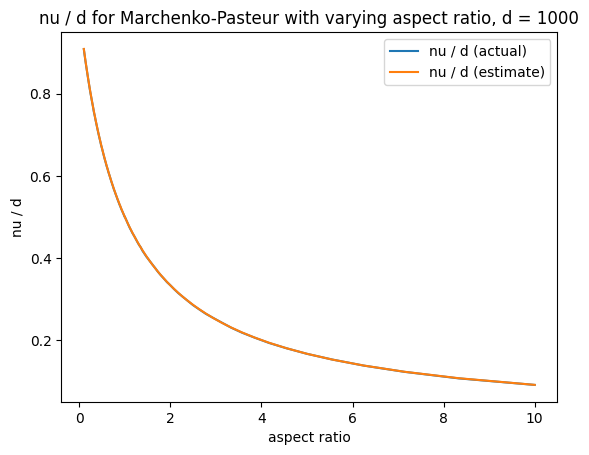

In [7]:
xx_aspect_ratios, xx_nu_over_d_vals, xx_estimate_nu_over_d_vals = get_hard_coded_vals()

this_title = "nu / d for Marchenko-Pasteur with varying aspect ratio, d = 1000"
plt.title(this_title)
plt.plot(xx_aspect_ratios, xx_nu_over_d_vals, label = "nu / d (actual)")
plt.plot(xx_aspect_ratios, xx_estimate_nu_over_d_vals, label = "nu / d (estimate)")
plt.xlabel("aspect ratio")
plt.ylabel("nu / d")
plt.legend()
plt.savefig('nu_over_d_MP_d_1000_one.pdf', dpi=300, bbox_inches='tight')
plt.show()

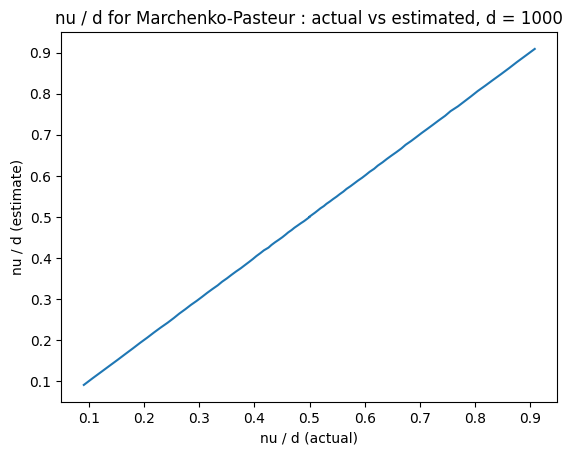

In [8]:
xx_aspect_ratios, xx_nu_over_d_vals, xx_estimate_nu_over_d_vals = get_hard_coded_vals()

this_title = "nu / d for Marchenko-Pasteur : actual vs estimated, d = 1000"
plt.title(this_title)
plt.plot(xx_nu_over_d_vals, xx_estimate_nu_over_d_vals)
plt.xlabel("nu / d (actual)")
plt.ylabel("nu / d (estimate)")
#plt.legend()
plt.savefig('nu_over_d_MP_d_1000_two.pdf', dpi=300, bbox_inches='tight')
plt.show()

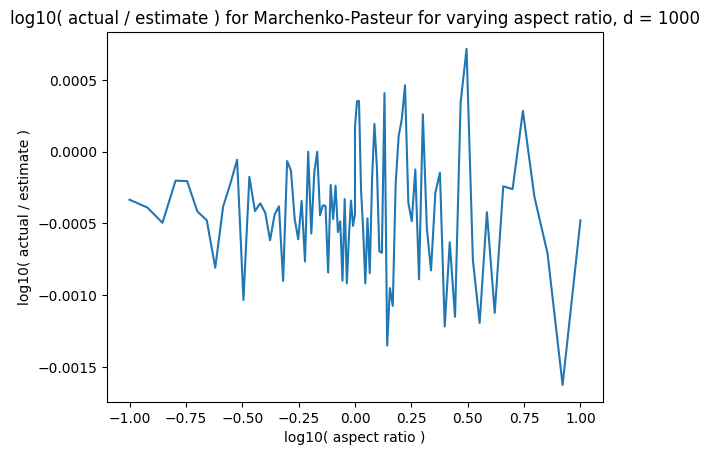

In [12]:
xx_aspect_ratios, xx_nu_over_d_vals, xx_estimate_nu_over_d_vals = get_hard_coded_vals()

# Apply the function using np.vectorize
this_vec_log10 = np.vectorize(pp.this_log10)
xx_log10_ratio = this_vec_log10(np.array(xx_nu_over_d_vals) / np.array(xx_estimate_nu_over_d_vals))

# Apply the function using np.vectorize
this_vec_abs = np.vectorize(pp.this_abs)
xx_abs_log10_ratio = this_vec_abs(xx_log10_ratio)

xx_log10_aspect_ratios = this_vec_log10(np.array(xx_aspect_ratios))

this_title = "log10( actual / estimate ) for Marchenko-Pasteur for varying aspect ratio, d = 1000"

plt.plot(xx_log10_aspect_ratios, xx_log10_ratio)
plt.xlabel("log10( aspect ratio )")
plt.ylabel("log10( actual / estimate )")
plt.title(this_title)
plt.savefig('nu_over_d_MP_d_1000_three.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
xx_aspect_ratios = pp.clean_array(np.array(these_aspect_ratios), num_decimal_places=4)
print("xx_aspect_ratios = ", xx_aspect_ratios)
print()

xx_nu_over_d_vals = pp.clean_array(np.array(nu_over_d_vals), num_decimal_places=4)
print("xx_nu_over_d_vals = ", xx_nu_over_d_vals)
print()
xx_estimate_nu_over_d_vals = pp.clean_array(np.array(estimate_nu_over_d_vals), num_decimal_places=4)
print("xx_estimate_nu_over_d_vals = ", xx_estimate_nu_over_d_vals)
print()

In [6]:
def get_hard_coded_vals() -> tuple:

    xx_aspect_ratios =  [0.1, 0.12, 0.14, 0.16, 0.18, 0.2, 0.22, 0.24, 0.26, 0.28, 0.3, 0.32, 0.34, 0.36, 0.38, 0.4, 0.42, 0.44, 0.46, 0.48, 0.5, 0.52, 0.54, 0.56, 0.58, 0.6, 0.62, 0.64, 0.66, 0.68, 0.7, 0.72, 0.74, 0.76, 0.78, 0.8, 0.82, 0.84, 0.86, 0.88, 0.9, 0.92, 0.94, 0.96, 0.98, 0.9999, 1.0, 1.0204, 1.0416, 1.0638, 1.0869, 1.1111, 1.1363, 1.1627, 1.1904, 1.2195, 1.2499, 1.282, 1.3157, 1.3513, 1.3888, 1.4285, 1.4705, 1.5151, 1.5624, 1.6129, 1.6666, 1.7241, 1.7857, 1.8518, 1.923, 1.9999, 2.0833, 2.1739, 2.2727, 2.3809, 2.5, 2.6315, 2.7777, 2.9411, 3.1249, 3.3333, 3.5714, 3.8461, 4.1666, 4.5454, 5.0, 5.5555, 6.2499, 7.1428, 8.3333, 10.0]

    xx_nu_over_d_vals =  [0.9083, 0.892, 0.8761, 0.8616, 0.847, 0.8325, 0.8187, 0.8049, 0.7929, 0.7808, 0.7691, 0.7557, 0.7459, 0.7345, 0.724, 0.7135, 0.7032, 0.6937, 0.6843, 0.6742, 0.6665, 0.6576, 0.6486, 0.6401, 0.6324, 0.6239, 0.6172, 0.6089, 0.6022, 0.5952, 0.5876, 0.5808, 0.5742, 0.567, 0.5614, 0.5549, 0.5491, 0.5427, 0.537, 0.5308, 0.5259, 0.5197, 0.5147, 0.5098, 0.5044, 0.4995, 0.5002, 0.4953, 0.4901, 0.4842, 0.4785, 0.4726, 0.4675, 0.4614, 0.4563, 0.4507, 0.4443, 0.4375, 0.4311, 0.4256, 0.4173, 0.4108, 0.4037, 0.3973, 0.3903, 0.3829, 0.3754, 0.3667, 0.3585, 0.3505, 0.3414, 0.3335, 0.3239, 0.3144, 0.3053, 0.2956, 0.2849, 0.2749, 0.264, 0.2539, 0.2428, 0.2303, 0.2181, 0.2061, 0.193, 0.1802, 0.1665, 0.1526, 0.1378, 0.1226, 0.1067, 0.0908]

    xx_estimate_nu_over_d_vals =  [0.909, 0.8928, 0.8771, 0.862, 0.8474, 0.8333, 0.8196, 0.8064, 0.7936, 0.7812, 0.7692, 0.7575, 0.7462, 0.7352, 0.7246, 0.7142, 0.7042, 0.6944, 0.6849, 0.6756, 0.6666, 0.6578, 0.6493, 0.641, 0.6329, 0.625, 0.6172, 0.6097, 0.6024, 0.5952, 0.5882, 0.5813, 0.5747, 0.5681, 0.5617, 0.5555, 0.5494, 0.5434, 0.5376, 0.5319, 0.5263, 0.5208, 0.5154, 0.5102, 0.505, 0.5, 0.5, 0.4949, 0.4897, 0.4845, 0.4791, 0.4736, 0.468, 0.4623, 0.4565, 0.4505, 0.4444, 0.4382, 0.4318, 0.4252, 0.4186, 0.4117, 0.4047, 0.3975, 0.3902, 0.3827, 0.375, 0.367, 0.3589, 0.3506, 0.3421, 0.3333, 0.3243, 0.315, 0.3055, 0.2957, 0.2857, 0.2753, 0.2647, 0.2537, 0.2424, 0.2307, 0.2187, 0.2063, 0.1935, 0.1803, 0.1666, 0.1525, 0.1379, 0.1228, 0.1071, 0.0909]

    return xx_aspect_ratios, xx_nu_over_d_vals, xx_estimate_nu_over_d_vals
